<div align="center">
<p style="text-align:center;color:#06344ef6;font-size:25px;font-family:bodoni MT">Ecole Nationale de la Statistique et de l'Analyse Economique Pierre NDIAYE (ENSAE) </br> 
</p>
<center><img src="https://ensai.fr/wp-content/uploads/2019/07/ENSAE-Dakar-logo.png"  width="100"></center>
<h1 style="font-family:'Bodoni MT', serif; color:#06344e; margin-top:15px;">CHURN SCORING — FORTUNEO BANK</h1>
<h3 style="font-family:'Times New Roman', serif; color:#444; font-weight:normal;">Notebook 01 — Analyse Exploratoire des Données (EDA)</h3>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

<table style="width:80%; margin:auto; font-family:'Times New Roman', serif; border-collapse:collapse;">
    <tr>
        <td style="width:55%; vertical-align:top; padding:10px 20px 10px 0; border-right:2px solid #06344e; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Réalisé par :</p>
            <ul style="font-size:15px; line-height:2; padding-left:20px; margin:0;">
                <li>Paul BALAFAI</li>
                <li>Ameth FAYE</li>
                <li>Sarah-Laure FOGWOUNG DJOUFACK</li>
                <li>Prosper LAWA FOUMSOU</li>
            </ul>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Elèves Ingénieurs Statisticiens Économistes
            </p>
        </td>
        <td style="width:45%; vertical-align:top; padding:10px 0 10px 20px; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Sous la supervision de :</p>
            <p style="font-size:15px; margin:4px 0;">Madame Mously DIAW</p>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Machine Learning Engineer<br>Formatrice IA
            </p>
        </td>
    </tr>
</table>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

</div>

### Identite du document
- **Objectif** : conduire l'analyse exploratoire complete du jeu de donnees clients avant nettoyage, feature engineering et modelisation.
- **Livrables** : diagnostic de qualite, analyses univariees et bivariees, visualisations et premiers constats metier.

### Contexte
Fortuneo Banque souhaite anticiper le churn de ses clients a partir d'informations demographiques, financieres et comportementales.

### Objectifs du notebook
1. Charger et inspecter les donnees brutes.
2. Verifier la qualite globale de la base.
3. Etudier la variable cible `Exited`.
4. Explorer les relations entre les variables et le churn.

# Table des matieres
- [Section 0 : Importation des packages](#section-0)
- [Section 1 : Configuration et initialisation](#section-1)
- [Section 2 : Chargement et controle de la base](#section-2)
- [Section 3 : Controle de qualite des donnees](#section-3)
- [Section 4 : Analyse univariee des variables quantitatives](#section-4)
- [Section 5 : Analyse univariee des variables qualitatives](#section-5)
- [Section 6 : Analyse bivariate avec la cible](#section-6)
- [Section 7 : Correlations et associations](#section-7)

<a id="section-0"></a>
# Section 0 : Importation des packages

## Packages principaux

In [1]:
import logging
import pandas as pd
from pathlib import Path

import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Impossible de localiser la racine du projet depuis le notebook.")

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from data.load_data import load_data_raw
from utils.config_loader import load_config, create_directories
from utils.eda_logger import setup_eda_logger

import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import seaborn as sns
import missingno as msno
from scipy.stats import skew, mannwhitneyu, chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="section-1"></a>
# Section 1 : Configuration et initialisation

## Parametres globaux

In [2]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')
COULEUR_PRINCIPALE = '#06344e'
COULEUR_CHURN      = '#e07b39'
PALETTE            = [COULEUR_PRINCIPALE, COULEUR_CHURN]

## Configuration Hydra
Chargement de la configuration centrale, initialisation du logger et preparation des repertoires du projet.

In [3]:
# Chargement de la configuration principale (Hydra)
cfg = load_config()

# Initialisation du logger
setup_eda_logger(cfg)
logger = logging.getLogger(__name__)

# Création des dossiers nécessaires é l'exécution (raw, interim, processed, reports, etc.)
create_directories(cfg)

2026-05-09 10:07:57,662 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\raw
2026-05-09 10:07:57,674 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\interim
2026-05-09 10:07:57,674 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed
2026-05-09 10:07:57,674 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\figures
2026-05-09 10:07:57,674 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\reports


In [4]:
NOTEBOOK_REPORT_DIR = PROJECT_ROOT / "reports" / "01_notebook"
IMAGES_DIR = NOTEBOOK_REPORT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_REPORT_DIR


WindowsPath('C:/Users/DELL/Desktop/ise2/Semestre2/Statistiques/Machine Learning 2/Projet_ML2/Projet_ML2_G8/reports/01_notebook')

<a id="section-2"></a>
# Section 2 : Chargement et controle de la base

## Chargement de la base

In [5]:
df_raw = load_data_raw(cfg)
n_rows, n_cols = df_raw.shape
logger.info(f"Dataset chargé ({n_rows} lignes, {n_cols} colonnes)")
df_raw.head()

2026-05-09 10:07:58,204 - data.load_data - INFO - DataFrame chargé : 165034 lignes, 14 colonnes
2026-05-09 10:07:58,424 - data.load_data - INFO -  Bank_churn.csv : Identique à la version précédente.
2026-05-09 10:07:58,424 - __main__ - INFO - Dataset chargé (165034 lignes, 14 colonnes)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


## Apercu de la base

In [6]:
# Copie de la base avant de faire des modifs
data = df_raw.copy()
print(f"La base de données a : {data.shape[0]:,} lignes x {data.shape[1]} colonnes")
data.head()

La base de données a : 165,034 lignes x 14 colonnes


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


<a id="section-3"></a>
# Section 3 : Controle de qualite des données

## Valeurs manquantes

In [7]:
display(data.isna().sum())
# Pas de valeurs manquantes

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Doublons

In [8]:
print("Nombre de doublon:", data.duplicated().sum())
# Il n'ya pas de doublon

Nombre de doublon: 0


## Variables identifiantes a exclure de la modelisation

In [9]:
data = data.drop(columns=['id', 'CustomerId','Surname'])

## Statistiques descriptives

In [10]:
data.describe(include="all")

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.000000,165034,165034,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
unique,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,94215,93150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,656.454373,NaN,NaN,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,NaN,NaN,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,NaN,NaN,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,NaN,NaN,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000


## Synthese du controle initial
L’analyse initiale met en évidence que la base de données contient 165 034 observations pour 14 variables, couvrant : des informations démographiques (Age, Gender, Geography), des informations financières (CreditScore, Balance, EstimatedSalary), des informations comportementales (Tenure, NumOfProducts, HasCrCard, IsActiveMember), ainsi que des variables d’identification (id, CustomerId, Surname) et une variable cible. Par ailleurs, cette base de données ne possede ni de valeur manquante ni de doublons.

Nous passons à présent à l'analyse exploratoire des données.

<a id="section-4"></a>
# Section 4 : Analyse univariee des variables quantitatives

## Types des variables

In [11]:
# types des variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  object 
 2   Gender           165034 non-null  object 
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Exited           165034 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 13.9+ MB


Les variables peuvent etre séparees en deux groupes :

- **Variables quantitatives** : `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary`
- **Variables qualitatives** : `Geography`, `Gender`, `HasCrCard`, `IsActiveMember`, `Exited`

## Analyse des variables quantitatives

### Statistiques descriptives

#### Tableau de synthese

In [12]:
var_quant = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
stats_desc = data[var_quant].describe().T
stats_desc['skewness'] = data[var_quant].skew().round(2) 
stats_desc['kurtosis'] = data[var_quant].kurt().round(2)
stats_desc.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
CreditScore,165034.0,656.45,80.10,350.00,597.00,659.0,710.00,850.00,-0.06,-0.07
Age,165034.0,38.13,8.87,18.00,32.00,37.0,42.00,92.00,0.97,1.53
Balance,165034.0,55478.09,62817.66,0.00,0.00,0.0,119939.52,250898.09,0.38,-1.60
EstimatedSalary,165034.0,112574.82,50292.87,11.58,74637.57,117948.0,155152.47,199992.48,-0.31,-0.84


### Histogrammes

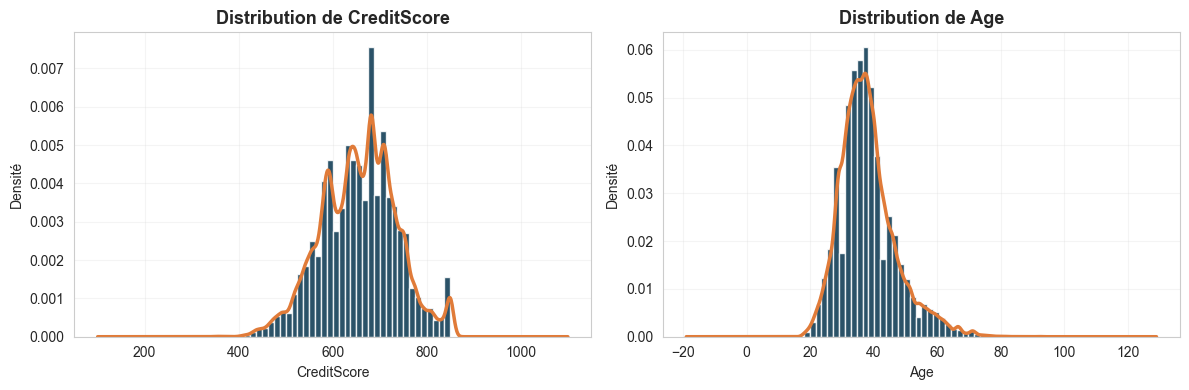

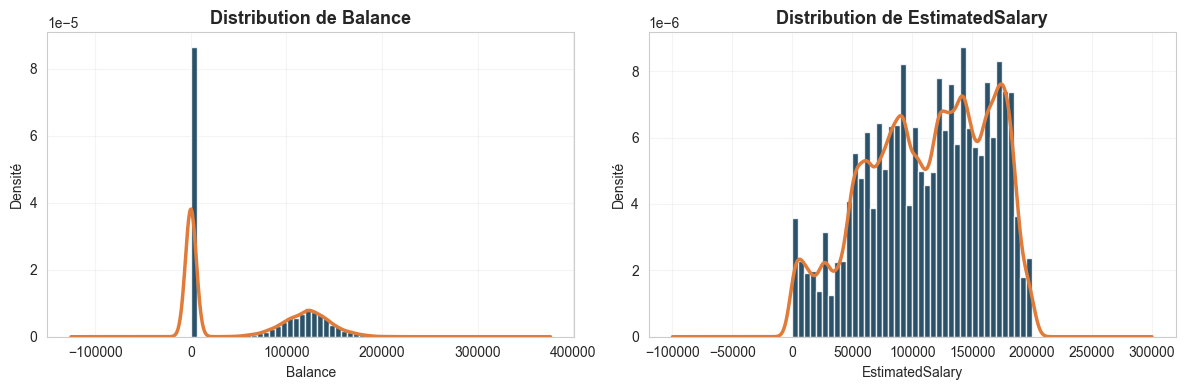

In [13]:
for i in range(0, len(var_quant), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    for j, col in enumerate(var_quant[i:i+2]):
        ax = axes[j]
        ax.hist(data[col], bins=40,color=COULEUR_PRINCIPALE,
                edgecolor='white', alpha=0.85, density=True)
        data[col].plot.kde(ax=ax,color=COULEUR_CHURN,linewidth=2.5)
        ax.set_title(f'Distribution de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Densité')
        ax.grid(alpha=0.2)
        fig2, ax2 = plt.subplots(figsize=(7,5))
        ax2.hist(data[col], bins=40,color=COULEUR_PRINCIPALE,
                 edgecolor='white', alpha=0.85, density=True)
        data[col].plot.kde(ax=ax2,color=COULEUR_CHURN,linewidth=2.5)
        ax2.set_title(f'Distribution de {col}')
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f"{col}_distribution.png", dpi=300, bbox_inches='tight')
        plt.close(fig2)

    plt.tight_layout()
    plt.show()


### Boxplots

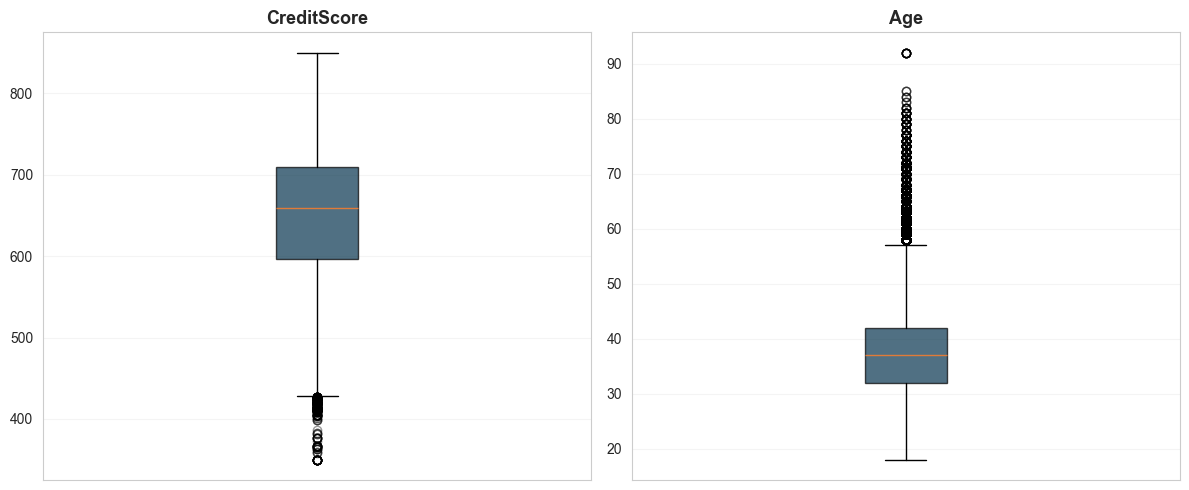

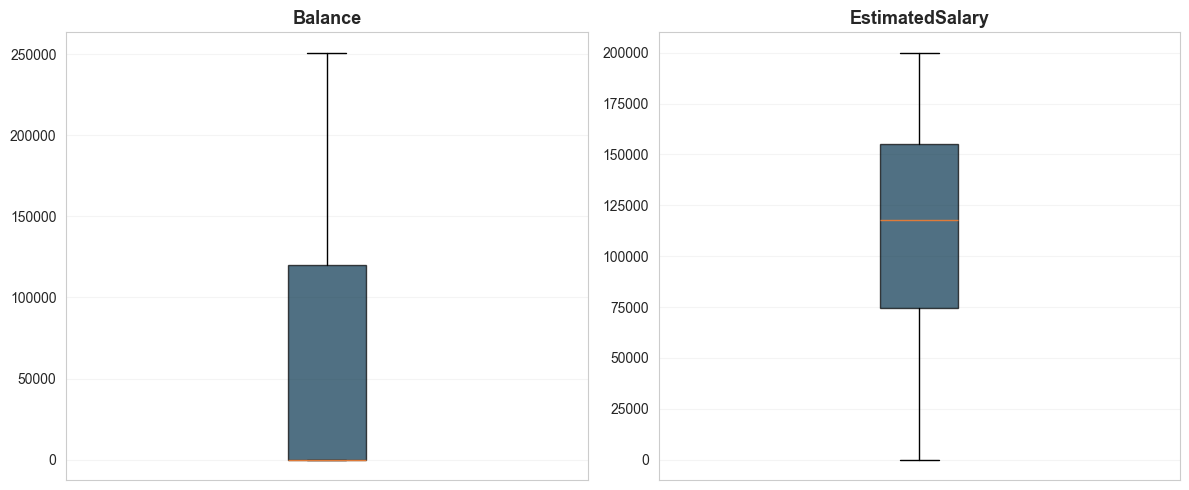

In [14]:
for i in range(0, len(var_quant), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    
    for j, col in enumerate(var_quant[i:i+2]):
        ax = axes[j]
        ax.boxplot(data[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=COULEUR_PRINCIPALE, alpha=0.7),
                   medianprops=dict(color=COULEUR_CHURN),
                   flierprops=dict(marker='o', color=COULEUR_CHURN, alpha=0.4))
        ax.set_title(col)
        ax.set_xticks([])
        ax.grid(axis='y', alpha=0.2)

        plt.figure(figsize=(6,4))
        plt.boxplot(data[col].dropna())
        plt.savefig(IMAGES_DIR / f"{col}_boxplot.png", dpi=300)
        plt.close()

    plt.tight_layout()
    plt.show()


### Analyse des variables quantitatives
`CreditScore` : distribution globalement symétrique (moyenne ≈ 656, médiane ≈ 659), avec une dispersion modérée et quelques valeurs faibles atypiques.

`Age` : asymétrie à droite (moyenne ≈ 38 ans), avec une concentration des clients entre 30 et 40 ans et la présence de nombreuses valeurs élevées.

`Balance` : médiane nulle et forte dispersion (écart-type ≈ 62 800), indiquant une proportion importante de clients sans solde et une grande variabilité des montants.

`EstimatedSalary` : distribution étalée (moyenne ≈ 112 575), avec une dispersion importante mais sans valeurs extrêmes marquées.

<a id="section-5"></a>
# Section 5 : Analyse univariée des variables qualitatives

## Frequences

In [15]:
var_qual = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited', 'NumOfProducts', 'Tenure']

for col in var_qual:
    freq = data[col].value_counts()
    freq_rel = (data[col].value_counts(normalize=True) * 100).round(2)
    df_freq = pd.DataFrame({'Effectif': freq, 'Fréquence (%)': freq_rel})
    print(f"\n--- {col} ---")
    print(df_freq.to_string())
    print()


--- Geography ---
           Effectif  Fréquence (%)
Geography                         
France        94215          57.09
Spain         36213          21.94
Germany       34606          20.97


--- Gender ---
        Effectif  Fréquence (%)
Gender                         
Male       93150          56.44
Female     71884          43.56


--- HasCrCard ---
           Effectif  Fréquence (%)
HasCrCard                         
1.0          124428           75.4
0.0           40606           24.6


--- IsActiveMember ---
                Effectif  Fréquence (%)
IsActiveMember                         
0.0                82885          50.22
1.0                82149          49.78


--- Exited ---
        Effectif  Fréquence (%)
Exited                         
0         130113          78.84
1          34921          21.16


--- NumOfProducts ---
               Effectif  Fréquence (%)
NumOfProducts                         
2                 84291          51.07
1                 77374       

## Focus sur la variable cible

2026-05-09 10:09:29,935 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:09:30,158 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


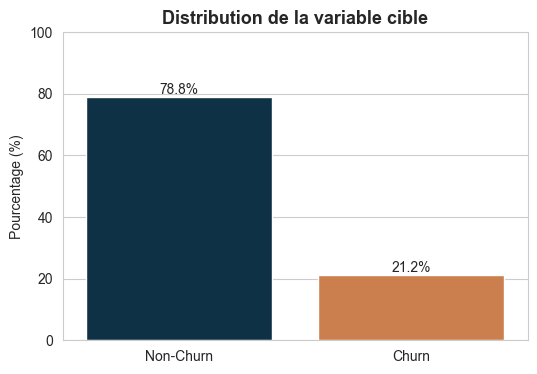

In [16]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Exited', data=data, palette=PALETTE)
ax.set_xticklabels(['Non-Churn', 'Churn'])
total = len(data)
for p in ax.patches:
    height = p.get_height()
    pct = height / total * 100
    p.set_height(pct)
    ax.text(p.get_x() + p.get_width()/2,pct + 1,f'{pct:.1f}%',ha='center')
plt.ylabel("Pourcentage (%)")
plt.xlabel("")
plt.title("Distribution de la variable cible")
plt.ylim(0, 100)
plt.savefig(IMAGES_DIR / "exited_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


## Diagrammes des autres variables qualitatives

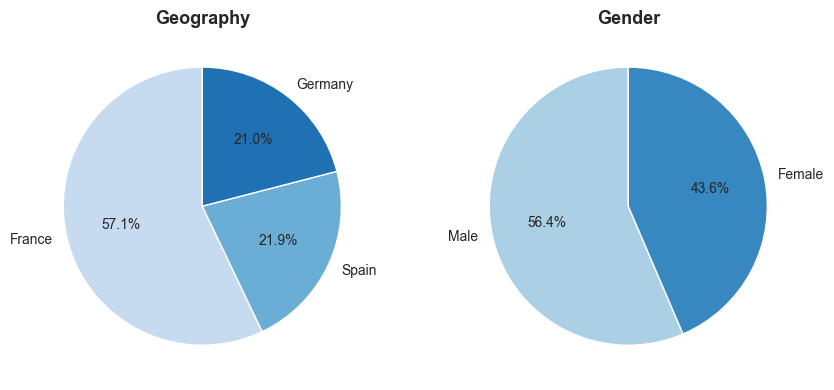

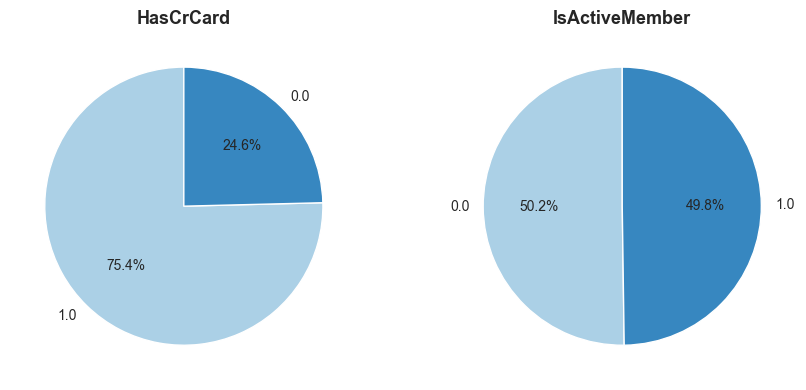

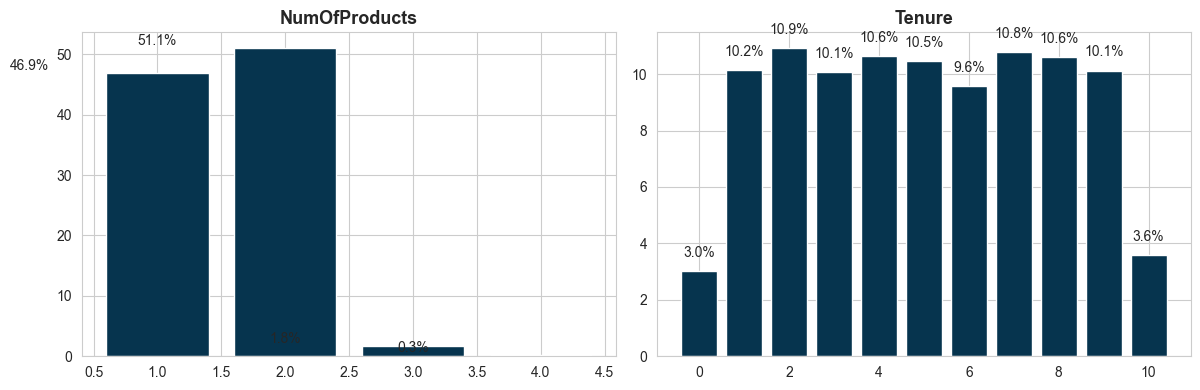

In [17]:
# PIE
var_qual_pie = ['Geography','Gender','HasCrCard','IsActiveMember']
for i in range(0, len(var_qual_pie), 2):
    fig, axes = plt.subplots(1, 2, figsize=(9,4))
    for j, col in enumerate(var_qual_pie[i:i+2]):
        freq = data[col].value_counts()
        axes[j].pie(freq.values,labels=freq.index, autopct=lambda p: f'{p:.1f}%' if p>2 else '',
                    colors=sns.color_palette("Blues", len(freq)),startangle=90)
        axes[j].set_title(col)
        plt.figure(figsize=(4,4))
        plt.pie(freq.values, labels=freq.index, autopct='%1.1f%%')
        plt.savefig(IMAGES_DIR / f"{col}_pie.png", dpi=300); plt.close()
    plt.tight_layout(); plt.show()
    
# BAR
var_qual_bar = ['NumOfProducts','Tenure']
for i in range(0, len(var_qual_bar), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    for j, col in enumerate(var_qual_bar[i:i+2]):
        freq = data[col].value_counts(normalize=True).sort_index()*100
        axes[j].bar(freq.index, freq.values, color=COULEUR_PRINCIPALE)
        axes[j].set_title(col)
        for k,v in enumerate(freq.values):
            axes[j].text(k, v+0.5, f'{v:.1f}%', ha='center')
        plt.figure(figsize=(5,4))
        plt.bar(freq.index, freq.values)
        plt.savefig(IMAGES_DIR / f"{col}_bar.png", dpi=300); plt.close()
    plt.tight_layout(); plt.show()


### Analyse des variables catégorielles
- `Geography` : la majorité des clients est localisée en France (≈ 57 %), tandis que l’Espagne et l’Allemagne représentent des proportions proches (≈ 22 % et 21 %).

- `Gender` : la distribution présente une forte proportion d'hommes (≈ 56 %) contre 44% de femmes.

- `HasCrCard` : une large majorité des clients possède une carte de crédit (≈ 75 %), indiquant une forte adoption de ce produit bancaire.

- `IsActiveMember` : la répartition entre clients actifs et inactifs est quasiment équilibrée (≈ 50 % chacun).

- `NumOfProducts` : la distribution est fortement concentrée sur 1 et 2 produits (≈ 98 % des clients), les modalités supérieures restant marginales.

- `Tenure` : la variable présente une répartition globalement homogène entre 1 et 9 ans (≈ 10 % par modalité), avec des extrêmes moins représentés (0 et 10 ans).

### Analyse de la variable cible
La variable cible Exited présente une distribution d'environ 78,8 % de clients non churn contre 21,2 % de clients churn. Ce déséquilibre de classes nous impose d'être vigilants quant au choix des métriques d'évaluation car par exemple, une bonne accuracy ne garantit pas forcément une bonne détection du churn.

<a id="section-6"></a>
# Section 6 : Analyse bivariée avec la cible

## Variables quantitatives et churn

### Histogrammes bivaries

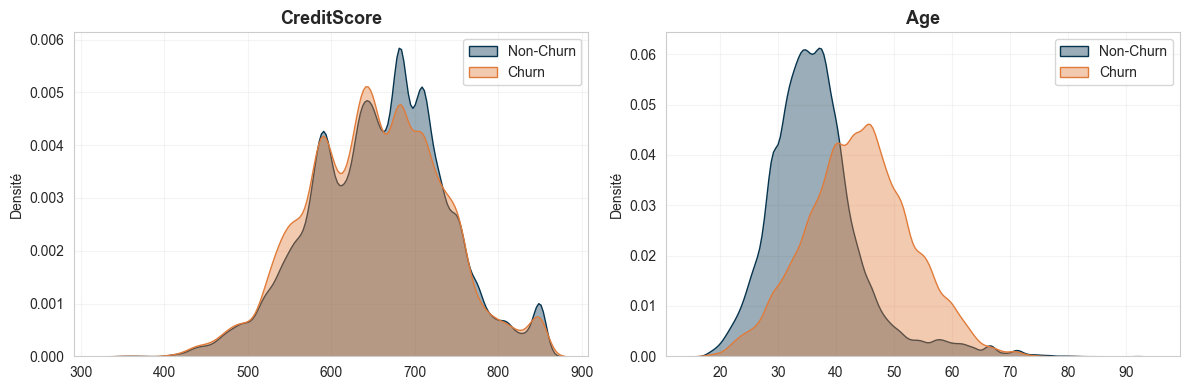

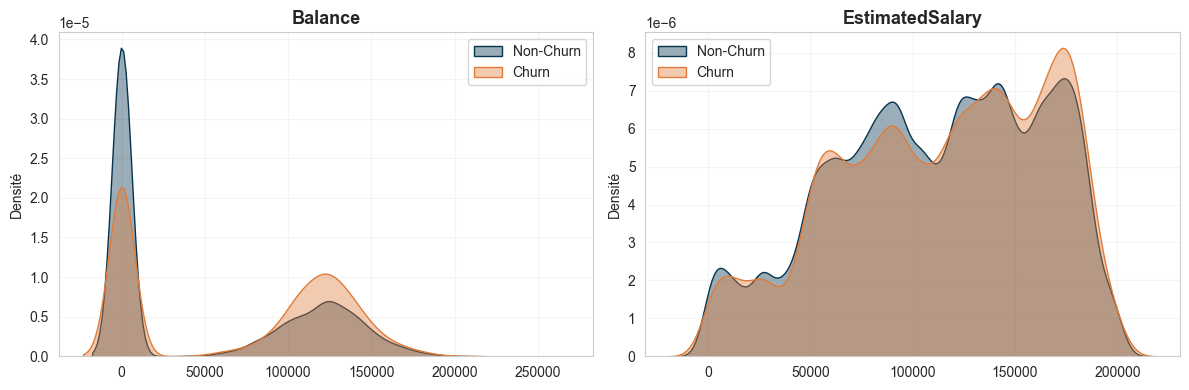

In [18]:
for i in range(0, len(var_quant), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    for j, col in enumerate(var_quant[i:i+2]):
        ax = axes[j]
        sns.kdeplot(data=data[data['Exited']==0][col], fill=True,
                    color=COULEUR_PRINCIPALE, alpha=0.4, label='Non-Churn', ax=ax)
        sns.kdeplot(data=data[data['Exited']==1][col], fill=True,
                    color=COULEUR_CHURN, alpha=0.4, label='Churn', ax=ax)
        ax.set_title(col)
        ax.set_xlabel(''); ax.set_ylabel('Densité')
        ax.legend()
        ax.grid(alpha=0.2)
        fig2, ax2 = plt.subplots(figsize=(6,4))
        sns.kdeplot(data=data[data['Exited']==0][col], fill=True,
                    color=COULEUR_PRINCIPALE, alpha=0.4, ax=ax2)
        sns.kdeplot(data=data[data['Exited']==1][col], fill=True,
                    color=COULEUR_CHURN, alpha=0.4, ax=ax2)
        ax2.set_title(col)
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f"{col}_kde_churn.png", dpi=300, bbox_inches='tight')
        plt.close(fig2)

    plt.tight_layout()
    plt.show()


### Boxplots bivariés

2026-05-09 10:10:02,153 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:02,433 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:02,869 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:03,143 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:03,

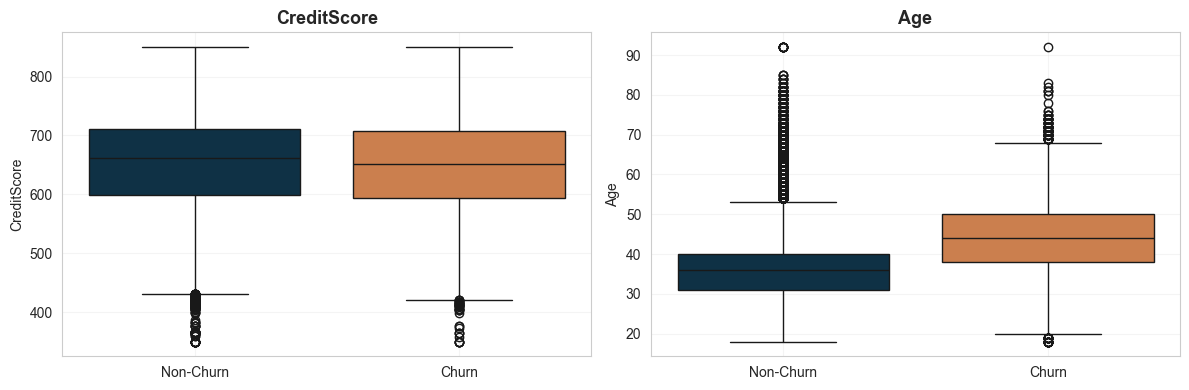

2026-05-09 10:10:06,114 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:06,345 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:06,754 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:07,035 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 10:10:07,

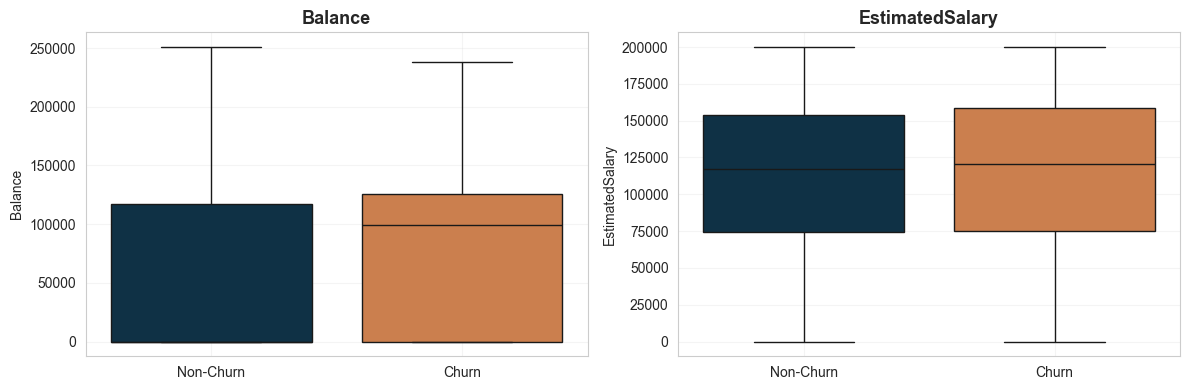

In [19]:
for i in range(0, len(var_quant), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    for j, col in enumerate(var_quant[i:i+2]):
        ax = axes[j]
        sns.boxplot(x='Exited', y=col, data=data, palette=PALETTE, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(''); ax.set_ylabel(col)
        ax.set_xticklabels(['Non-Churn','Churn'])
        ax.grid(alpha=0.2)
        fig2, ax2 = plt.subplots(figsize=(6,4))
        sns.boxplot(x='Exited', y=col, data=data, palette=PALETTE, ax=ax2)
        ax2.set_title(col)
        ax2.set_xticklabels(['Non-Churn','Churn'])
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f"{col}_boxplot_churn.png", dpi=300, bbox_inches='tight')
        plt.close(fig2)

    plt.tight_layout()
    plt.show()


In [20]:
stats = data.groupby('Exited')[var_quant].agg(['mean','median','std']).round(2)
stats

CreditScore                  Age                Balance            \
              mean median    std   mean median   std      mean    median   
Exited                                                                     
0           657.59  662.0  79.79  36.56   36.0  8.15  51255.81      0.00   
1           652.22  651.0  81.14  43.96   44.0  9.00  71209.98  98955.87   

                 EstimatedSalary                       
             std            mean     median       std  
Exited                                                 
0       62189.98       112084.29  116977.89  50214.66  
1       62646.69       114402.50  120892.96  50542.03

### Analyse bivariée des variables quantitatives avec la variable cible
L’analyse des variables quantitatives en fonction du statut de churn met en évidence des différences entre les deux groupes.

- `CreditScore` : les distributions sont très proches entre churn et non-churn, avec des moyennes similaires (≈ 652 vs 658). Cette variable semblerait peu discriminante pour expliquer le churn.
- `Age` : une différence marquée apparaît. Les clients churn sont en moyenne plus âgés (≈ 44 ans contre ≈ 36 ans), ce qui suggère que le risque de départ augmenterait avec l’âge.
- `Balance` : les clients churn présentent des soldes significativement plus élevés (médiane ≈ 98 956 contre 0 pour les non-churn). Cela indique que les clients disposant de fonds importants sembleraient plus susceptibles de quitter la banque.
- `EstimatedSalary` : les distributions sont très proches entre les deux groupes, avec des moyennes similaires. Cette variable ne semblerait pas jouer un rôle déterminant dans le churn.

Dans l’ensemble, Age et Balance apparaissent comme les variables les plus discriminantes, contrairement à CreditScore et EstimatedSalary.

## Variables qualitatives et churn

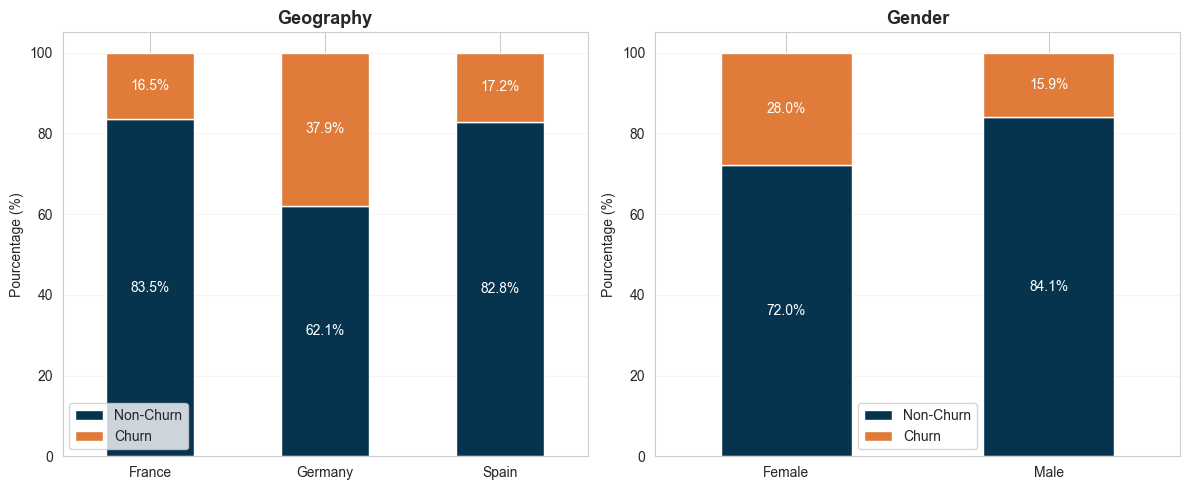

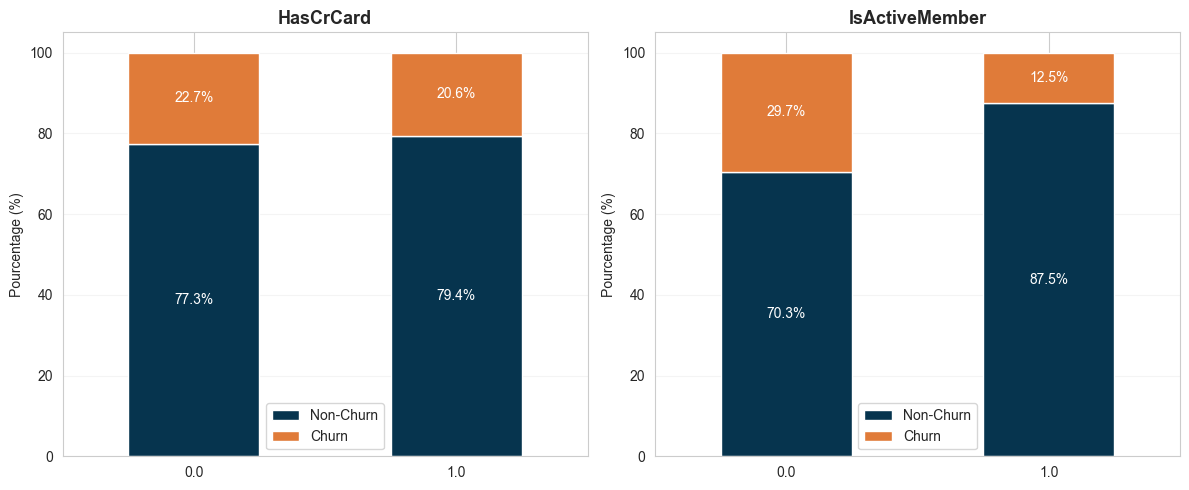

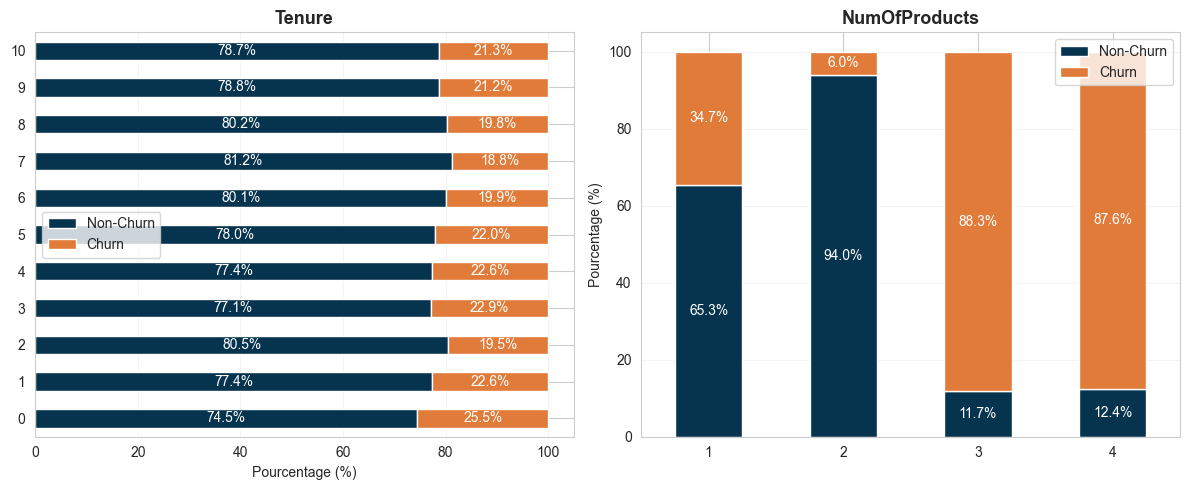

In [21]:
var_qual_exp = ['Geography','Gender','HasCrCard','IsActiveMember','Tenure','NumOfProducts']

for i in range(0, len(var_qual_exp), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for j, col in enumerate(var_qual_exp[i:i+2]):
        ax = axes[j]
        ct = pd.crosstab(data[col], data['Exited'], normalize='index') * 100
        kind = 'barh' if col=='Tenure' else 'bar'
        ct.plot(kind=kind, stacked=True, color=PALETTE, edgecolor='white', ax=ax)
        ax.set_title(col)
        ax.set_xlabel('Pourcentage (%)' if col=='Tenure' else '')
        ax.set_ylabel('' if col=='Tenure' else 'Pourcentage (%)')
        ax.legend(['Non-Churn','Churn'])
        ax.grid(axis='x' if col=='Tenure' else 'y', alpha=0.2)
        if col!='Tenure':
            ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        for c in ax.containers:
            labels = [f'{v:.1f}%' if v>5 else '' for v in c.datavalues]
            ax.bar_label(c, labels=labels, label_type='center', fontsize=10, color='white')
        fig2, ax2 = plt.subplots(figsize=(6,5 if col=='Tenure' else 4))
        ct.plot(kind=kind, stacked=True, color=PALETTE, edgecolor='white', ax=ax2)
        ax2.set_title(col)
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / f"{col}_churn.png", dpi=300, bbox_inches='tight')
        plt.close(fig2)
    plt.tight_layout()
    plt.show()


### Analyse bivariée des variables qualitatives
- `Geography` : le churn est plus élevé en Allemagne (≈ 38 %) qu’en France et en Espagne (≈ 17 %).
- `Gender` : les femmes présentent un taux de churn plus élevé (≈ 28 %) que les hommes (≈ 16 %).
- `HasCrCard` : peu de différence entre les groupes (≈ 21–23 %), variable peu discriminante.
- `IsActiveMember` : les clients inactifs churn beaucoup plus (≈ 30 %) que les actifs (≈ 12 %).
- `NumOfProducts` : relation très forte ; les clients avec 3 ou 4 produits présentent un churn très élevé (> 85 %), tandis que ceux avec 2 produits churn très peu (≈ 6 %).
- `Tenure` : pas de tendance claire ; les taux de churn restent relativement stables selon l’ancienneté.

<a id="section-7"></a>
# Section 7 : Correlations et associations

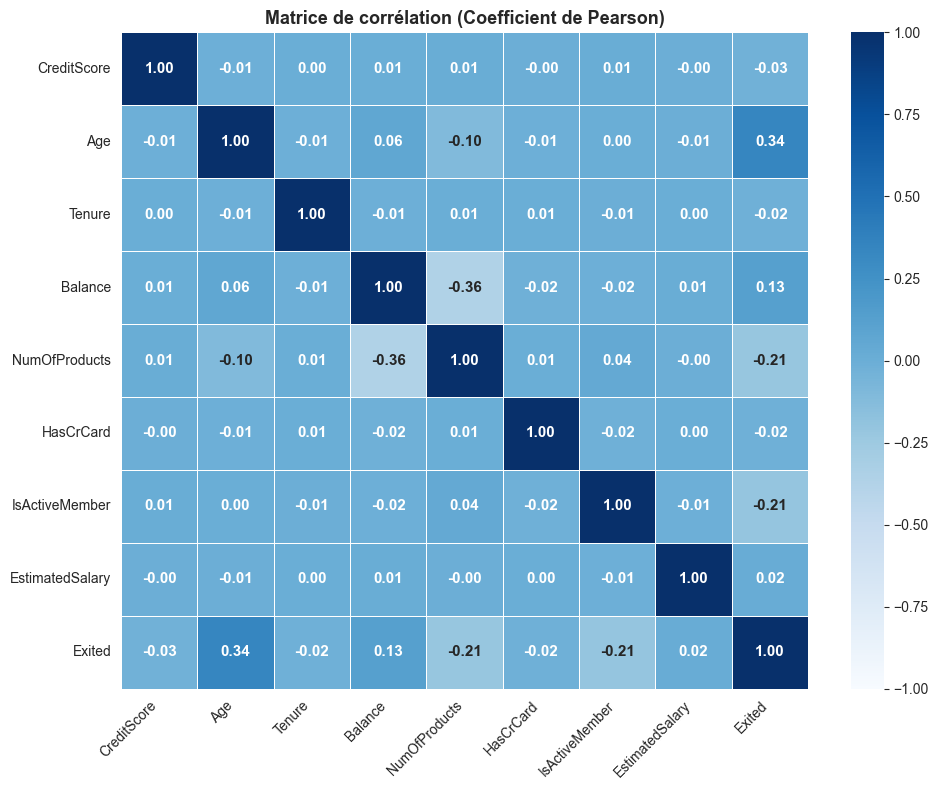

In [22]:
corr_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
             'HasCrCard','IsActiveMember','EstimatedSalary','Exited']

corr = data[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap='Blues', vmin=-1, vmax=1,
            linewidths=0.5,
            annot_kws={'size':11,'weight':'bold'})
plt.title("Matrice de corrélation (Coefficient de Pearson)")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "pearson_correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


### Analyse de la matrice de corrélation
Les corrélations entre variables explicatives numériques sont faibles, indiquant une absence de dépendance forte entre elles.

Ainsi, aucune redondance significative n’est détectée, ce qui justifie la conservation de l’ensemble des variables pour la modélisationredondance.

## Correlation avec la variable cible

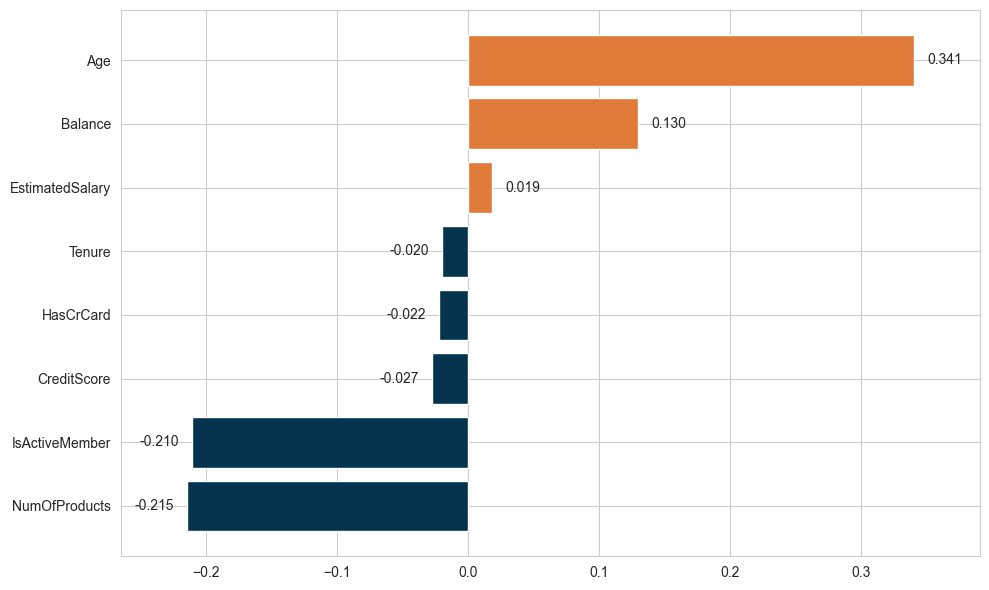

In [23]:
# On extrait uniquement la ligne/colonne Exited de la matrice
# Corrélation positive : quand la variable augmente, le churn augmente
# Corrélation négative : quand la variable augmente, le churn diminue

corr_exited = corr['Exited'].drop('Exited').sort_values()
colors = [COULEUR_CHURN if v > 0 else COULEUR_PRINCIPALE for v in corr_exited]
plt.figure(figsize=(10,6))
plt.barh(corr_exited.index, corr_exited.values, color=colors)
plt.xlim(corr_exited.min()-0.05, corr_exited.max()+0.05)
for i, v in enumerate(corr_exited):
    plt.text(v + (0.01 if v>=0 else -0.01), i, f'{v:.3f}',
             va='center', ha='left' if v>=0 else 'right')
plt.subplots_adjust(left=0.25)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "correlation_exited.png", dpi=300)
plt.show()


### Analyse de la corrélation avec la variable cible
Les corrélations avec le churn restent globalement faibles, mais certaines variables se distinguent.

- `Age` présente la corrélation positive la plus élevée (≈ 0,34), indiquant que le churn augmente avec l’âge.
- `Balance` est faiblement corrélée positivement (≈ 0,13), suggérant un effet limité.
- `NumOfProducts` (≈ -0,22) et IsActiveMember (≈ -0,21) sont les variables les plus négativement corrélées, indiquant que les clients engagés et multi-équipés sont moins susceptibles de churn.
- Les autres variables (CreditScore, Tenure, HasCrCard, EstimatedSalary) ont des corrélations proches de zéro.

## Associations entre variables qualitatives

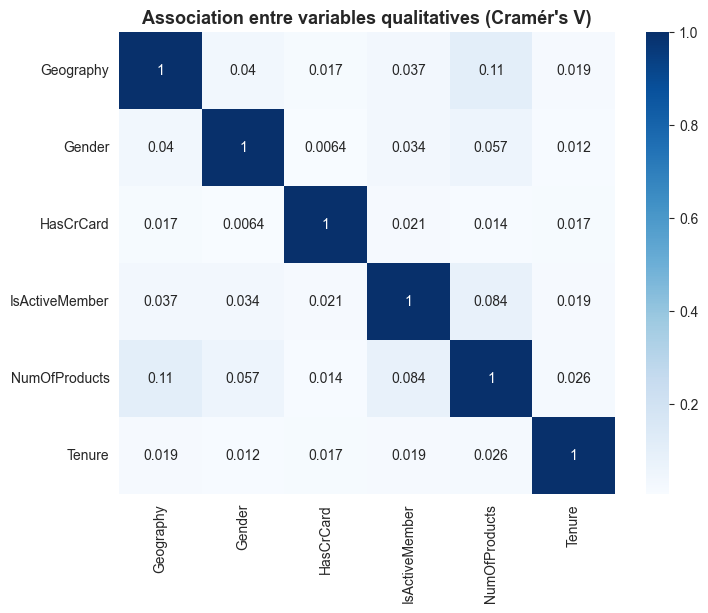

In [24]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

# matrice de dépendance
var_qual = ['Geography','Gender','HasCrCard','IsActiveMember','NumOfProducts','Tenure']
cramer_matrix = pd.DataFrame(index=var_qual, columns=var_qual)
for v1 in var_qual:
    for v2 in var_qual:
        cramer_matrix.loc[v1, v2] = cramers_v(data[v1], data[v2])
cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(8,6))
sns.heatmap(cramer_matrix, annot=True, cmap='Blues')
plt.title("Association entre variables qualitatives (Cramér's V)")
plt.savefig(IMAGES_DIR / "VCramer_ssociation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


### Analyse des associations entre variables qualitatives
Les valeurs dV et Crar V sont globalement faibles (toutes < 0,12), indiquant une absence de dépendance notable entre les variables qualitative.

La relation la plus élevée est observée entre Geography et NumOfProducts (≈ 0,11), mais elle reste faiue.

Ainsi, aucuoe redondance significative n’est détectée entre les variables qualitatives, ce qui justifie leur conservation pour la modélisation. pour la modélisation.

## **A suivre**

02_notebook_processing_feature_engineering